In [1]:
import networkx as nx
network = nx.read_graphml("celebrities_clean_without_content.graphml")

In [2]:
example_item = list(network.nodes(data=True))[0]
print(example_item)

('0', {'Name': 'Alexander I of Yugoslavia', 'NameURL': 'Alexander_I_of_Yugoslavia', 'Link': 'https://en.wikipedia.org/wiki/Alexander_I_of_Yugoslavia', 'birthcity': 'CETINJE', 'countryName': nan, 'continentName': 'EUROPE', 'birthyear': 1888.0, 'deathyear': 1934.0, 'gender': 'Male', 'occupation': 'POLITICIAN', 'industry': 'GOVERNMENT'})


In [3]:
periods = [
    (-float('inf'), 30, "No god yet"),
    (30, 325, "Early Christianity"),
    (325, 1054, "Nicaea to East–West Schism"),
    (1054, 1517, "East–West Schism to Reformation"),
    (1517, 1760, "Reformation to industrial era"),
    (1760, 1840, "industrial era"),
    (1840, 1945, "wartime"),
    (1945, 2000, "post war"),
    (2000, 2025, "lately")
]

In [4]:
era_subgraphs = {}
for start, end, label in periods:

    subgraph = network.subgraph([n for n, attr in network.nodes(data=True) if (attr.get("birthyear") <= end) and attr.get("deathyear") >= start])
    print(f"Period: {label}, Number of nodes: {subgraph.number_of_nodes()}")
    era_subgraphs[label] = subgraph

Period: No god yet, Number of nodes: 534
Period: Early Christianity, Number of nodes: 262
Period: Nicaea to East–West Schism, Number of nodes: 578
Period: East–West Schism to Reformation, Number of nodes: 683
Period: Reformation to industrial era, Number of nodes: 858
Period: industrial era, Number of nodes: 1025
Period: wartime, Number of nodes: 4666
Period: post war, Number of nodes: 7203
Period: lately, Number of nodes: 5542


In [5]:
examples = era_subgraphs["Early Christianity"]
itesm = list(examples.nodes(data=True))
print(itesm[0:5])

[('4584', {'Name': 'Pope Julius I', 'NameURL': 'Pope_Julius_I', 'Link': 'https://en.wikipedia.org/wiki/Pope_Julius_I', 'birthcity': 'ROME', 'countryName': 'ITALY', 'continentName': 'EUROPE', 'birthyear': 300.0, 'deathyear': 352.0, 'gender': 'Male', 'occupation': 'RELIGIOUS FIGURE', 'industry': 'RELIGION'}), ('10944', {'Name': 'Decebalus', 'NameURL': 'Decebalus', 'Link': 'https://en.wikipedia.org/wiki/Decebalus', 'birthcity': 'OTHER', 'countryName': 'UNKNOWN', 'continentName': 'UNKNOWN', 'birthyear': 50.0, 'deathyear': 106.0, 'gender': 'Male', 'occupation': 'POLITICIAN', 'industry': 'GOVERNMENT'}), ('7286', {'Name': 'Paul of Tarsus', 'NameURL': 'Paul_of_Tarsus', 'Link': 'https://en.wikipedia.org/wiki/Paul_of_Tarsus', 'birthcity': 'TARSUS', 'countryName': 'TURKEY', 'continentName': 'ASIA', 'birthyear': 5.0, 'deathyear': 67.0, 'gender': 'Male', 'occupation': 'RELIGIOUS FIGURE', 'industry': 'RELIGION', 'redirectNameURL': 'Paul the Apostle'}), ('10865', {'Name': 'Antipope Novatian', 'NameUR

In [6]:
def node_by_name(G, name):
    for n in G.nodes:
        if getattr(n, "name", None) == name:
            return n

In [7]:
source = node_by_name(network, "Donald Trump")
target = node_by_name(network, "Jesus Christ")

In [8]:
popes_in_periods = {}
for period, subgraph in era_subgraphs.items():
    pope_nodes = [
        (n, attr) for n, attr in subgraph.nodes(data=True)
        if isinstance(attr.get("Name"), str) and "Pope" in attr.get("Name") and attr.get("occupation") == "RELIGIOUS FIGURE"
    ]
    popes_in_periods[period] = pope_nodes
    print(f"Period: {period}, Number of popes: {len(pope_nodes)}")


Period: No god yet, Number of popes: 4
Period: Early Christianity, Number of popes: 36
Period: Nicaea to East–West Schism, Number of popes: 124
Period: East–West Schism to Reformation, Number of popes: 76
Period: Reformation to industrial era, Number of popes: 35
Period: industrial era, Number of popes: 10
Period: wartime, Number of popes: 13
Period: post war, Number of popes: 7
Period: lately, Number of popes: 3


In [9]:
examples = popes_in_periods["No god yet"]
for e in examples:
    print(e)


('4501', {'Name': 'Pope Anacletus', 'NameURL': 'Pope_Anacletus', 'Link': 'https://en.wikipedia.org/wiki/Pope_Anacletus', 'birthcity': 'ROME', 'countryName': 'ITALY', 'continentName': 'EUROPE', 'birthyear': 1.0, 'deathyear': 88.0, 'gender': 'Male', 'occupation': 'RELIGIOUS FIGURE', 'industry': 'RELIGION'})
('5517', {'Name': 'Pope Evaristus', 'NameURL': 'Pope_Evaristus', 'Link': 'https://en.wikipedia.org/wiki/Pope_Evaristus', 'birthcity': 'BETHLEHEM', 'countryName': 'PALESTINE', 'continentName': 'ASIA', 'birthyear': 1.0, 'deathyear': 107.0, 'gender': 'Male', 'occupation': 'RELIGIOUS FIGURE', 'industry': 'RELIGION'})
('4595', {'Name': 'Pope Linus', 'NameURL': 'Pope_Linus', 'Link': 'https://en.wikipedia.org/wiki/Pope_Linus', 'birthcity': 'VOLTERRA', 'countryName': 'ITALY', 'continentName': 'EUROPE', 'birthyear': 1.0, 'deathyear': 76.0, 'gender': 'Male', 'occupation': 'RELIGIOUS FIGURE', 'industry': 'RELIGION'})
('4525', {'Name': 'Pope Clement I', 'NameURL': 'Pope_Clement_I', 'Link': 'https

In [ ]:
import networkx as nx

def get_undirected_neighbors(node, network):
    """
    Returns a list of neighbors for a specific node, treating all edges 
    as undirected regardless of the graph type.
    """
    # Check if the node exists to avoid generic errors later
    if node not in network:
        raise ValueError(f"Node {node} not found in the network.")

    if network.is_directed():

        in_neighbors = set(network.predecessors(node))
        out_neighbors = set(network.successors(node))
        return list(in_neighbors | out_neighbors)
    else:
        return list(network.neighbors(node))

In [11]:
import os

In [ ]:
def get_wikilink_content(node_id, network, folder_path="wikipages"):
    """
    Finds a node by ID, retrieves its 'NameURL' attribute, and reads 
    the corresponding text file from the specified folder.
    
    Args:
        node_id: The ID of the node to look up.
        network: The NetworkX graph object.
        folder_path: The directory where text files are stored (default: 'wikilinks').
        
    Returns:
        str: The content of the text file.
        
    Raises:
        ValueError: If node is not found or NameURL is missing.
        FileNotFoundError: If the text file does not exist.
    """
    
    # 1. Check if node exists in the network
    if node_id not in network:
        raise ValueError(f"Node ID '{node_id}' not found in the network.")
    
    # 2. Get the node's attributes
    node_data = network.nodes[node_id]
    
    # 3. Retrieve the NameURL attribute
    name_url = node_data.get("NameURL")
    
    if not name_url:
        raise ValueError(f"Node '{node_id}' does not have a 'NameURL' attribute.")
    
    # 4. Construct the file path
    filename = f"{name_url}.txt"
    file_path = os.path.join(folder_path, filename)
    
    # 5. Read and return the file content
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find file: {file_path}")
    except IOError as e:
        raise IOError(f"Error reading file {file_path}: {e}")


In [13]:
neighbors = get_undirected_neighbors(examples[1][0], network)

In [14]:
text_ex = get_wikilink_content('5517', network)

Wordcloud preparation

In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [16]:
# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\boton\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import re
import string

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    # --- 1. CLEANING ---
    
    # Remove Refs/Citations first (content inside <ref> is usually not main text)
    text = re.sub(r'<ref[^>]*>.*?</ref>', '', text, flags=re.DOTALL)
    
    # Remove HTML comments
    text = re.sub(r'', '', text, flags=re.DOTALL)
    
    # Remove URLs (keep this aggressive as per your request)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove File/Image/Category links completely (e.g., [[File:Image.jpg]])
    text = re.sub(r'\[\[(File|Category|Image):[^\]]+\]\]', '', text, flags=re.IGNORECASE)

    # Handle Wikilinks: [[Target|Display]] -> keep "Display". [[Target]] -> keep "Target"
    # This regex looks for optional text before a pipe |, and captures what follows.
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)

    # Remove Templates.
    text = re.sub(r'\{\{[^}]+\}\}', '', text)
    
    # Remove remaining HTML tags but keep content between them
    text = re.sub(r'<[^>]+>', ' ', text)

    # --- 2. NORMALIZATION ---
    
    # Lowercase
    text = text.lower()
    
    # Handle Punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    
    # Remove extra whitespace created by replacements
    text = re.sub(r'\s+', ' ', text).strip()

    # --- 3. TOKENIZATION & FILTERING ---
    
    tokens = text.split()
    cleaned_tokens = []
    
    for token in tokens:
        # Skip stop words
        if token in stop_words:
            continue
        
        # Skip digits/special chars (keep only alphabetic)
        if not token.isalpha():
            continue
            
        # Adjusted Length filter
        if len(token) < 2: 
            continue
        if len(token) > 20:
            continue
            
        # Lemmatize
        lemmatized = lemmatizer.lemmatize(token)
        cleaned_tokens.append(lemmatized)

    return cleaned_tokens

In [18]:
print(text_ex)


{{Short description|Head of the Catholic Church from c. 99 to c. 107}}
{{redirect|Aristus|other people with this name|Aristus (disambiguation)}}
{{Infobox Christian leader
| type = Pope
| honorific-prefix = [[Pope Saint]]
| name = Evaristus
| title = [[Bishop of Rome]]
| image = Pope Saint Evaristus (by Sandro Botticelli) – Sistine Chapel (1481).jpg
| caption = Pope Evaristus, 15th century
| term_start = {{circa}} 100
| term_end = {{circa}} 108
| predecessor = [[Clement of Rome|Clement I]]
| successor = [[Pope Alexander I|Alexander I]]
| birth_date = 
| birth_place = [[Bethlehem]], [[Judaea (Roman province)|Judaea]], [[Roman Empire]]
| death_date = {{circa}} 108
| death_place = [[Rome]], [[Roman Italy|Italy]], [[Roman Empire]]
| parents = Judah
| feast_day = 26 October
| church = [[Early Church]]
}}
'''Pope Evaristus''' ([[Greek language|Greek]]: Ευάριστος) was the [[bishop of Rome]] from {{Circa}} 99/100 to his death in 107/108.<ref>{{CathEncy|wstitle=Pope St. Evaristus}}</ref><ref>Ac

In [19]:
ex_tokens = clean_and_tokenize(text_ex)

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

def create_wordcloud_from_tokens(tokens, title="Word Cloud", colormap='viridis'):
    """
    Generates a word cloud from a list of tokenized strings.
    Example input: ['apple', 'banana', 'apple', 'cherry']
    """
    # 1. Safety Check
    if not tokens or len(tokens) == 0:
        print("Cannot generate WordCloud: Input token list is empty.")
        return
    tokens = [str(t).strip() for t in tokens if '\n' not in str(t)]

    # 2. Count frequencies manually
    word_counts = Counter(tokens)

    # 3. Configure WordCloud
    wc = WordCloud(
        width=1200, 
        height=800,
        background_color='white',
        colormap=colormap,
        max_words=150,
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_counts)

    # 4. Plotting
    plt.figure(figsize=(12, 10))
    plt.imshow(wc, interpolation='bilinear')
    
    # Styling
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

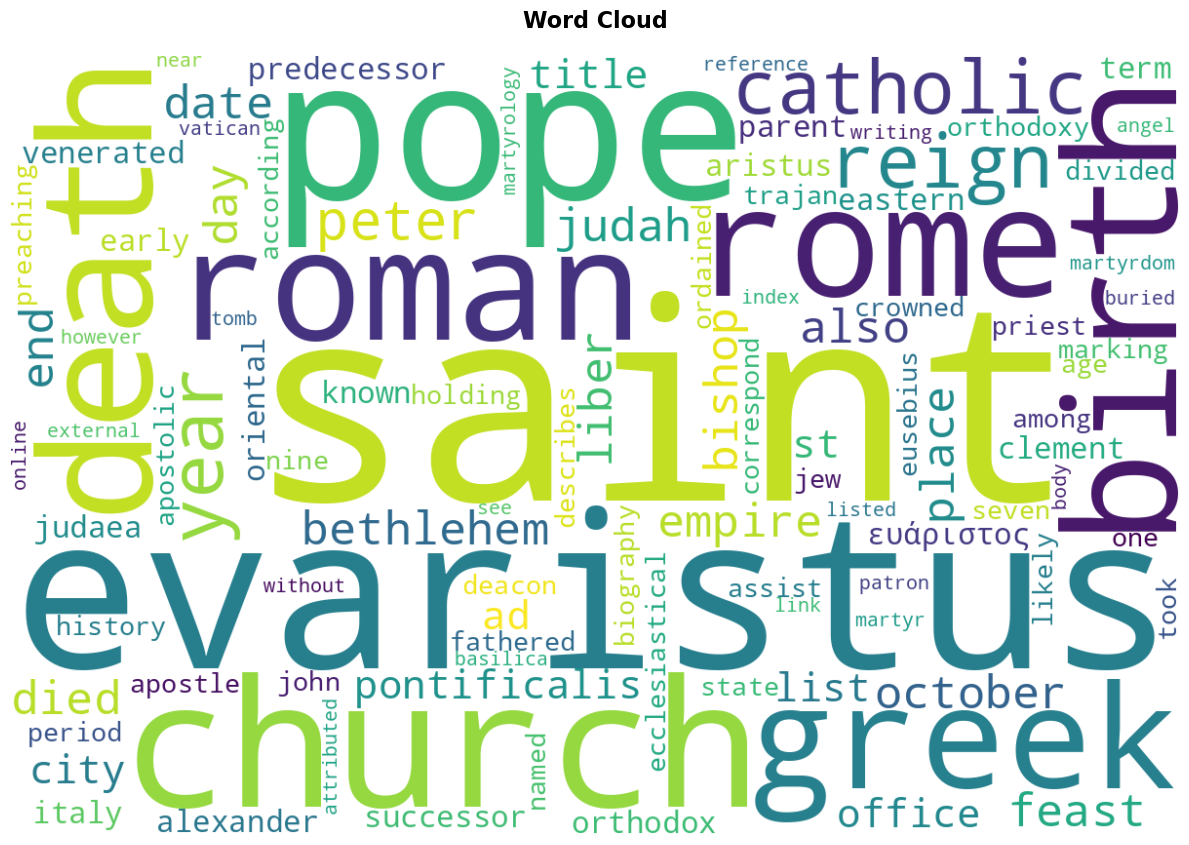

In [26]:
create_wordcloud_from_tokens(ex_tokens)

In [35]:
def get_wordcloud_of_pope_era(era):
    jumbo_tokens = []
    target_popes = popes_in_periods[era]
    for pope in target_popes:
        neighbors = get_undirected_neighbors(pope[0], network)
        for n in neighbors:
            relevant_tokens = clean_and_tokenize(get_wikilink_content(n, network))
            jumbo_tokens += relevant_tokens

    create_wordcloud_from_tokens(jumbo_tokens, title=f"Keywords for {era} era popes", colormap='viridis')


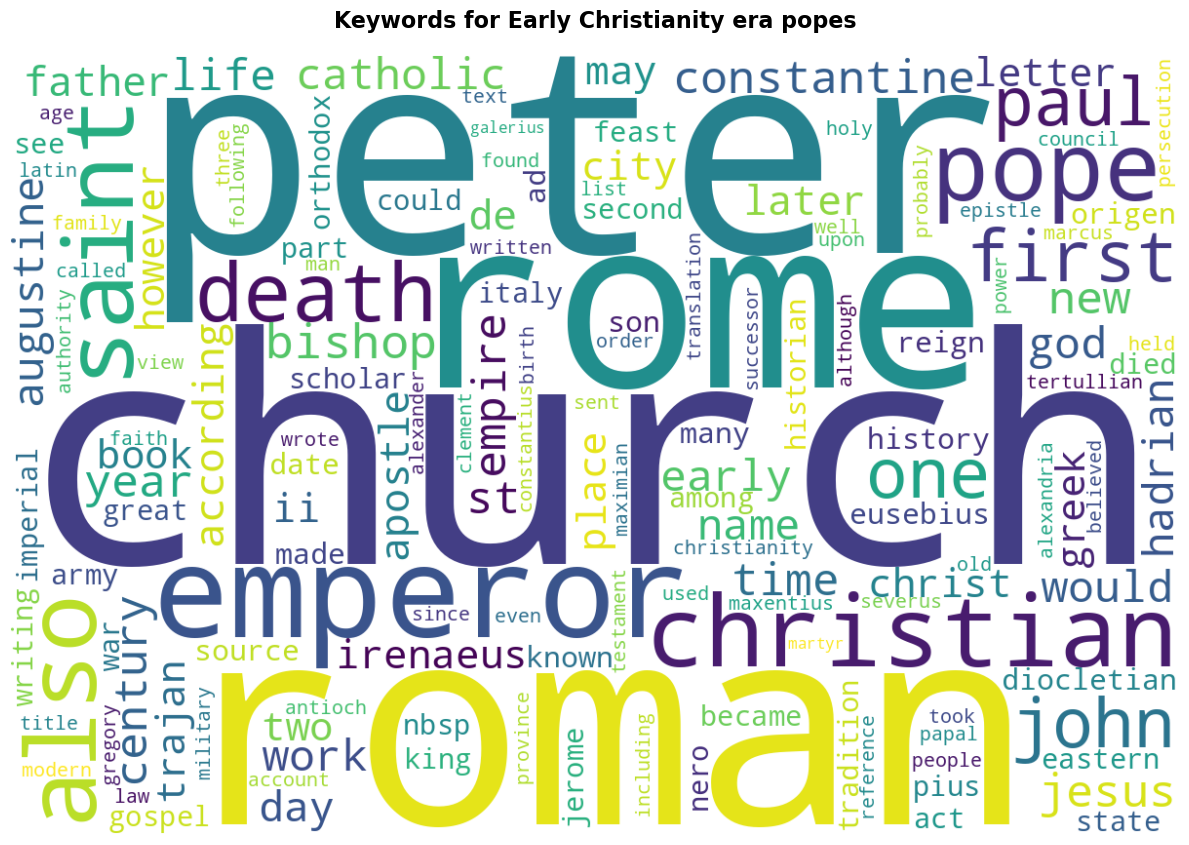

In [36]:
get_wordcloud_of_pope_era("Early Christianity")

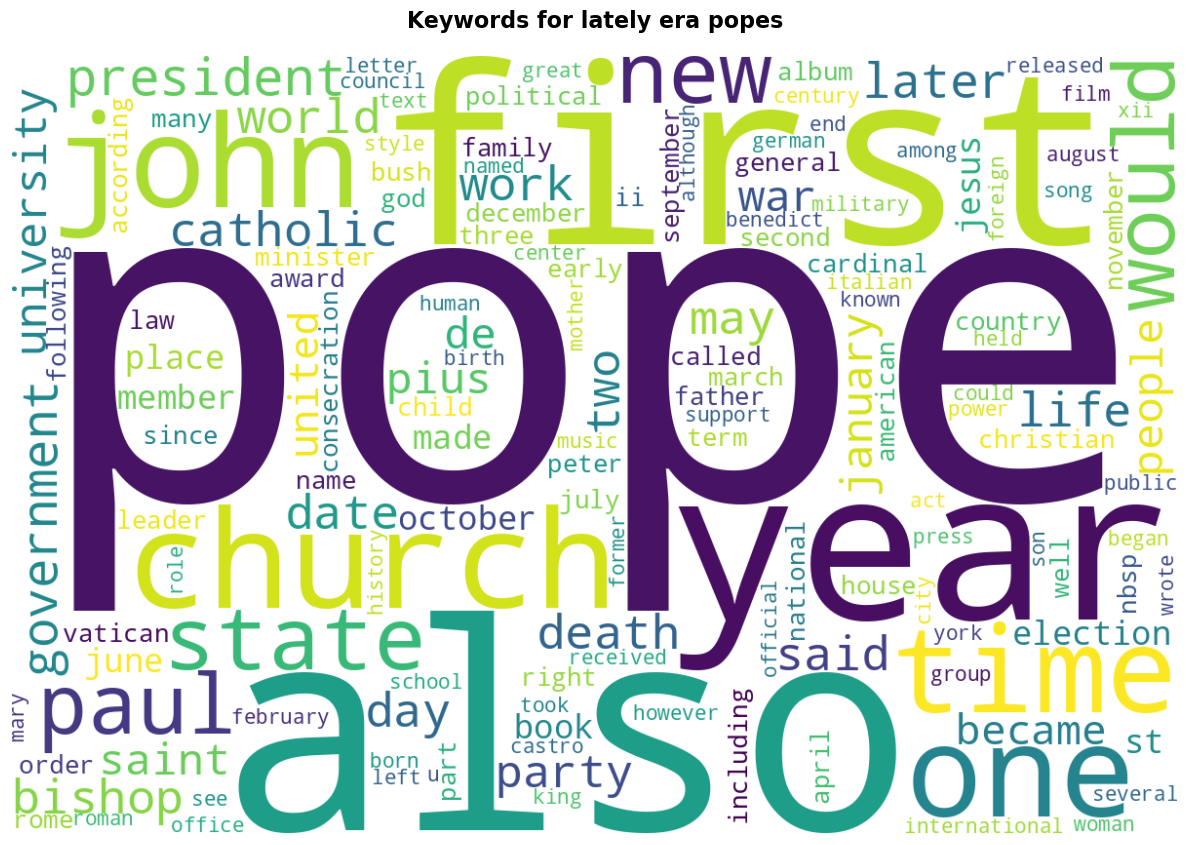

In [46]:
get_wordcloud_of_pope_era("lately")

In [28]:
a = ["a", "b"]
b = ["c", "d"]
a += b

In [32]:
!pip install "Pillow==9.5.0"

  Using cached Pillow-9.5.0-cp311-cp311-win_amd64.whl.metadata (9.7 kB)
Using cached Pillow-9.5.0-cp311-cp311-win_amd64.whl (2.5 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 12.0.0
    Uninstalling pillow-12.0.0:
      Successfully uninstalled pillow-12.0.0


  You can safely remove it manually.


In [ ]:
import os
import difflib

folder_path = "wikipages"


def batch_fix_filenames(target_folder, target_names):
    # Get list of files currently on disk
    try:
        files_on_disk = os.listdir(target_folder)
    except FileNotFoundError:
        print(f"Error: Folder '{target_folder}' not found.")
        return

    count_fixed = 0

    for correct_name in target_names:
        correct_filename = f"{correct_name}.txt"
        
        # Check if the clean file already exists
        if correct_filename in files_on_disk:
            # File is already perfect, skip it
            continue
            
        # If not found, look for a "messy" match
        # cutoff=0.6 means "if it looks 60% similar, it's probably the one"
        matches = difflib.get_close_matches(correct_filename, files_on_disk, n=1, cutoff=0.6)
        
        if matches:
            messy_filename = matches[0]
            
            # Construct full paths
            old_path = os.path.join(target_folder, messy_filename)
            new_path = os.path.join(target_folder, correct_filename)
            
            try:
                # RENAME THE FILE
                os.rename(old_path, new_path)
                print(f"✅ Fixed: '{messy_filename}'  ->  '{correct_filename}'")
                
                # Update our local list so we don't try to fix it again
                files_on_disk.remove(messy_filename)
                files_on_disk.append(correct_filename)
                count_fixed += 1
                
            except OSError as e:
                print(f"❌ Failed to rename {messy_filename}: {e}")
        else:
            print(f"⚠️ Could not find any file resembling: {correct_filename}")

    print(f"\n--- Complete. Renamed {count_fixed} files. ---")
all_names = []
for a, n in network.nodes(data=True):
    all_names.append(n["NameURL"])

batch_fix_filenames(folder_path, all_names)

✅ Fixed: 'Claude_Make╠üle╠üle╠ü.txt'  ->  'Claude_Makélélé.txt'
✅ Fixed: 'Dejan_Savic╠üevic╠ü.txt'  ->  'Dejan_Savićević.txt'
✅ Fixed: 'Franc╠ºois_Bozize╠ü.txt'  ->  'François_Bozizé.txt'
✅ Fixed: 'Jose╠ü_Bosingwa.txt'  ->  'José_Bosingwa.txt'
✅ Fixed: 'Jose╠ü_Ramos-Horta.txt'  ->  'José_Ramos-Horta.txt'
✅ Fixed: 'Le╠üon_M'ba.txt'  ->  'Léon_M'ba.txt'
✅ Fixed: 'Milo_─Éukanovic╠ü.txt'  ->  'Milo_Đukanović.txt'
✅ Fixed: 'Mirko_Vuc╠îinic╠ü.txt'  ->  'Mirko_Vučinić.txt'
✅ Fixed: 'Predrag_Mijatovic╠ü.txt'  ->  'Predrag_Mijatović.txt'
✅ Fixed: 'Radovan_Karadz╠îic╠ü.txt'  ->  'Radovan_Karadžić.txt'
✅ Fixed: 'Stevan_Jovetic╠ü.txt'  ->  'Stevan_Jovetić.txt'
✅ Fixed: 'Xanana_Gusma╠âo.txt'  ->  'Xanana_Gusmão.txt'
✅ Fixed: 'Ama╠änulla╠äh_Kha╠än.txt'  ->  'Amānullāh_Khān.txt'
✅ Fixed: 'Houari_Boume╠üdienne.txt'  ->  'Houari_Boumédienne.txt'
✅ Fixed: 'Jose╠ü_Eduardo_dos_Santos.txt'  ->  'José_Eduardo_dos_Santos.txt'
✅ Fixed: 'Manucho_Gonc╠ºalves.txt'  ->  'Manucho_Gonçalves.txt'
✅ Fixed: 'Alfredo_D